In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt

In [2]:
from os import getcwd
from os.path import join

file_name = 'ab_data.csv'

df = pd.read_csv(join(getcwd(), file_name))

### Analise Exploratória

In [3]:
df.sample(4)

,user_id,timestamp,group,landing_page,converted
282865,753429,11:29.8,treatment,new_page,0
163463,669779,38:25.9,control,old_page,0
14911,770057,36:13.5,control,old_page,0
275919,770938,01:08.1,control,old_page,0


In [4]:
# Analisando a quantidade de registros por grupo e pagina
df.groupby(['group', 'landing_page']).agg({'converted': 'count'}).reset_index()

,group,landing_page,converted
0,control,new_page,1928
1,control,old_page,145274
2,treatment,new_page,145313
3,treatment,old_page,1965


In [5]:
# Filtrando exclusivamente os grupos de tratamento e controle com as paginas de analise
df_cleaned = df[
    (df['group'] == 'treatment') & (df['landing_page'] == 'new_page') |
    (df['group'] == 'control') & (df['landing_page'] == "old_page")
]

# Removendo usuarios que estejam em ambos os grupos
df_cleaned = df_cleaned.drop_duplicates('user_id')

In [6]:
# Verificando a taxa de conversão das paginas
df_cleaned.groupby(['group']).agg({'landing_page': 'count', 'converted': ['sum', 'mean']}).reset_index()

group landing_page converted          
                    count       sum      mean
0    control       145274     17489  0.120386
1  treatment       145311     17264  0.118807

### Teste de hipótese

- Referência: https://medium.com/data-hackers/teste-de-hip%C3%B3tese-uma-ferramenta-poderosa-para-tomadas-de-decis%C3%A3o-baseadas-em-evid%C3%AAncias-6e260d3067ba

O objetivo de comparar a taxa de conversão entre duas páginas, sendo uma delas o grupo controle (exposto à página antiga) e a outra o grupo de tratamento (exposto à página nova), pode ser abordado por um `teste unilateral à direita quando temos uma hipótese direcional` clara de que a página nova terá uma taxa de conversão maior.

#### Hipóteses para o Teste Z de Proporções

**H0 (Hipótese Nula):** A taxa de conversão da página nova (tratamento) é menor ou igual à taxa de conversão da página antiga (controle).

$$ H_0: p_{\text{tratamento}} \leq p_{\text{controle}} $$

**H1 (Hipótese Alternativa):** A taxa de conversão da página nova (tratamento) é maior do que a taxa de conversão da página antiga (controle).

$$ H_1: p_{\text{tratamento}} > p_{\text{controle}} $$


`A princípio, a hipótese nula é considerada verdadeira e o teste fornecerá evidências estatísticas para rejeitá-la ou não.`

<br>
<img src="https://www.kdnuggets.com/wp-content/uploads/statisticaltesttree.png" alt="Statistical Test Tree" width="600"/>

O `Teste Z para proporções`:
   
Especificamente projetado para comparar duas proporções amostrais e determinar se há uma diferença estatisticamente significativa entre elas.

```
Quando comparamos duas proporções amostrais para verificar se há uma diferença significativa, utilizamos o Teste Z, que se baseia na distribuição normal padrão. A ideia é que, sob a hipótese nula (H0), a diferença entre as proporções amostrais tratamento e controle segue aproximadamente uma distribuição normal padrão, especialmente quando os tamanhos das amostras são grandes.
```


<br>
<img src="https://miro.medium.com/v2/resize:fit:1400/1*sljp3pO2nR9p8Go_xwWUOA.png" alt="standard normal distribution" width="600"/>

A partir das proporções observadas e seus respectivos tamanhos de amostra, calculamos um valor Z, que é a diferença padronizada entre as proporções amostrais. Este valor Z indica quantos desvios padrão nossa observação está distante da média esperada sob H0.

- Referências: 
    - https://en.wikipedia.org/wiki/Z-test
    - https://en.wikipedia.org/wiki/Two-proportion_Z-test

No Teste Z para proporções, a fórmula utilizada é:

$$ Z = \frac{\hat{p}_\text{tratamento} - \hat{p}_\text{controle}}{\sqrt{\hat{p}_\text{combinada}(1-\hat{p}_\text{combinada}) \left( \frac{1}{n_\text{controle}} + \frac{1}{n_\text{tratamento}} \right)}} $$

Onde:
- $\hat{p}_\text{tratamento}$ é a proporção de conversão no grupo de tratamento.
- $\hat{p}_\text{controle}$ é a proporção de conversão no grupo de controle.
- $n_\text{controle}$ é o tamanho da amostra do grupo de controle.
- $n_\text{tratamento}$ é o tamanho da amostra do grupo de tratamento.
- $\hat{p}_\text{combinada}$ é a proporção combinada de conversões, calculada como:
    $$ \hat{p}_\text{combinada} = \frac{x_{1} + x_{2}}{n_{1} + n_{2}} $$
    - $x_{1}$ e $x_{2}$ são as contagens de sucessos (conversões) nas duas amostras
    - $n_{1}$ e $n_{2}$ são os tamanhos das amostras para os grupos de controle e tratamento, respectivamente.

In [7]:
# Dados dos grupos controle e tratamento
n_controle = df_cleaned.loc[df_cleaned.group == 'control'].converted.count()        # tamanho da amostra para controle
x_controle = df_cleaned.loc[df_cleaned.group == 'control'].converted.sum()          # número de conversões no grupo controle
n_tratamento = df_cleaned.loc[df_cleaned.group == 'treatment'].converted.count()    # tamanho da amostra para tratamento
x_tratamento = df_cleaned.loc[df_cleaned.group == 'treatment'].converted.sum()      # número de conversões no grupo tratamento

print('n1:', n_controle)
print('n2:', n_tratamento)

print('x1:', x_controle)
print('x2:', x_tratamento)

n1: 145274
n2: 145311
x1: 17489
x2: 17264


In [8]:
# Calcular as proporções de conversão
p_controle = x_controle / n_controle
p_tratamento = x_tratamento / n_tratamento

print('P_controle:', p_controle)
print('P_tratamento:', p_tratamento)

P_controle: 0.1203863045004612
P_tratamento: 0.11880724790277405


In [9]:
# Calcular a proporção combinada
p_combinada = (x_controle + x_tratamento) / (n_controle + n_tratamento)

print('P_combinada:', p_combinada)

P_combinada: 0.11959667567149027


In [10]:
# Calcular o valor Z
z = (p_tratamento - p_controle) / np.sqrt(p_combinada * (1 - p_combinada) * (1/n_controle + 1/n_tratamento))

print('Z_calculado:', z)

Z_calculado: -1.3116075339133115


---
### IMPORTANTE

**Interpretação de um Valor Z Negativo em um Teste Unilateral à Direita:**

Quando realizamos um teste unilateral à direita para comparar as taxas de conversão de duas páginas — esperando que a página nova (tratamento) tenha uma taxa de conversão maior que a página antiga (controle) — , um valor $ z_{calculado} $ negativo indica que a taxa de conversão observada na página de tratamento é menor do que na página de controle, o que inclusive pode ser observado analisando diretamente a taxa de conversão calculada. 

Isso, por si só, já nos informa que a hipótese alternativa $ H_1: p_{\text{tratamento}} > p_{\text{controle}} $ não é suportada pelos dados.

Apesar da conclusão acima, para fins de estudo e aprendizado, vou continuar com o cálculo do $ z_{crítico} $, pois este valor é útil para entender o processo de decisão em testes de hipóteses e este é o intuito do estudo.

---

### Determinação do Valor Crítico Z

- Referencias:
    -   https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval

- **Nível de Significância**: Representado por α, é a probabilidade máxima que se está disposto a aceitar de cometer um erro tipo I (rejeitar H0 quando ela é verdadeira).

- **Nível de Confiança:** É a probabilidade de que uma afirmação esteja correta sobre a população, com base na amostra. Nível de Confiança = 1 − α

- **Intervalo de Confiança:** intervalo de valores usados ​​para estimar um `parâmetro estatístico` desconhecido, como por exemplo uma média ou desvio padrão da população.
    

    Para um intervalo de `confiança de 95%` e teste `bilateral`, a fórmula é:

    $$ \left( \hat{p}_\text{tratamento} - \hat{p}_\text{controle} \right) \pm Z_{\frac{\alpha}{2}} \sqrt{\frac{\hat{p}_\text{controle}(1-\hat{p}_\text{controle})}{n_\text{controle}} + \frac{\hat{p}_\text{tratamento}(1-\hat{p}_\text{tratamento})}{n_\text{tratamento}}} $$

    **Onde:**
    - $\hat{p}_\text{controle}$ é a proporção de conversão no grupo de controle.
    - $\hat{p}_\text{tratamento}$ é a proporção de conversão no grupo de tratamento.
    - $n_\text{controle}$ e $n_\text{tratamento}$ são os tamanhos das amostras.
    - $Z_{\frac{\alpha}{2}}$ é o valor crítico da distribuição normal padrão correspondente ao nível de confiança desejado.

    e para este caso, o teste `unilateral à direita` fica:

    $$ \left( \hat{p}_\text{tratamento} - \hat{p}_\text{controle} \right) - Z_{\alpha} \sqrt{\frac{\hat{p}_\text{controle}(1-\hat{p}_\text{controle})}{n_\text{controle}} + \frac{\hat{p}_\text{tratamento}(1-\hat{p}_\text{tratamento})}{n_\text{tratamento}}} $$

    sendo:
    - $ Z_{\alpha} $ é o valor crítico da distribuição normal padrão para um teste unilateral à direita.

**Z Crítico:**

O valor crítico é um número limite que usado para decidir se o resultado do teste estatístico é compatível com a hipótese nula ou se é tão extremo que se deve rejeitá-la.

Com o nível de significância α escolhido, consulta-se a [tabela de distribuição normal](https://images.squarespace-cdn.com/content/v1/533db07de4b0d9f7ba7f1e77/1596733728743-8835EAH1Q1ZY22FGODN3/positive+z-score+table) para encontrar o valor crítico Z.

- Se o valor Z calculado for maior que o valor crítico Z, rejeita a hipótese nula (H0), concluindo que há evidências de que a página nova tem uma taxa de conversão maior.
- Se o valor Z calculado for menor ou igual ao valor crítico Z, não rejeita a hipótese nula, indicando que não há evidências suficientes para afirmar que a página nova tem uma taxa de conversão maior.

**P-Valor:**

O p-valor é a probabilidade associada ao valor Z calculado. Para um teste unilateral à direita, calcula o p-valor como a área sob a curva à direita do valor Z calculado.

- Se o p-valor for menor que α, rejeita a hipótese nula.
- Se o p-valor for maior ou igual a α, não rejeita a hipótese nula

In [11]:
# nivel de significancia (area de rejeição)
alpha = 0.05

In [12]:
# area de aceitacao para teste unilateral a direita
area_aceitacao = 1 - alpha

print(f'{area_aceitacao:.4f}')

0.9500


<img src="..\Teste AB\z_critico.png" alt="zcritico" width="600"/>

Como o valor da area de aceitação não está disponivel na tabela, podemos descobrir por interpolação.

Calculo por interpolação: 

$$ z_{critico} = z_1 + \left( \frac{A - A_1}{A_2 - A_1} \right) \cdot (z_2 - z_1) $$

**Onde:**
- $A$ = área desejada
- $A_1$, $A_2$ = áreas conhecidas mais próximas
- $z_1$, $z_2$ = valores de $z$ correspondentes a $A_1$ e $A_2$


In [13]:
# calculando Z critico conforme tabela por interpolação

A = 0.9500
A1 = 0.9495
A2 = 0.9505
z1 = 1.64
z2 = 1.65

# Interpolação linear
z_critico = z1 + ((A - A1) / (A2 - A1)) * (z2 - z1)

if z > z_critico:
    print("Rejeitamos a hipótese nula. Há evidências de que a página nova converte mais.")
else:
    print("Não rejeitamos a hipótese nula. Não há evidências suficientes para afirmar que a página nova converte mais.")

print(f"Z:", z)
print(f"Z_critico:", z_critico)

Não rejeitamos a hipótese nula. Não há evidências suficientes para afirmar que a página nova converte mais.
Z: -1.3116075339133115
Z_critico: 1.6449999999999994


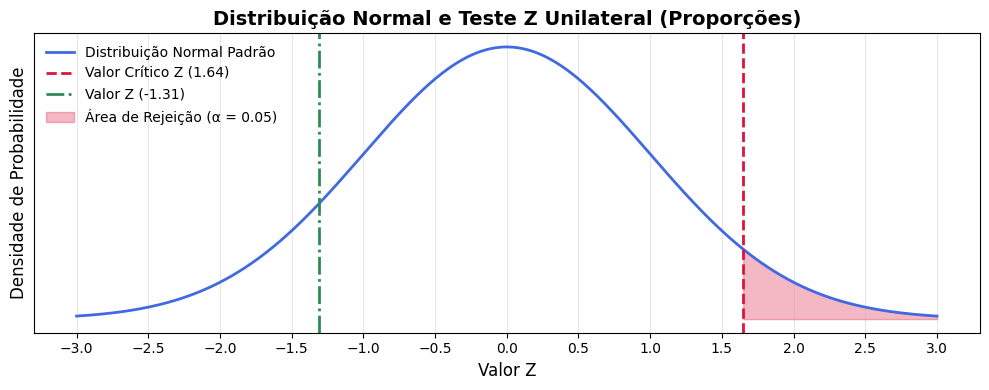

In [14]:
# Sequência de valores e função densidade
x = np.linspace(-3, 3, 1000)
y = st.norm.pdf(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y, color='royalblue', linewidth=2, label='Distribuição Normal Padrão')

# Valor Z crítico
plt.axvline(x=z_critico, color='crimson', linestyle='--', linewidth=2, label=f'Valor Crítico Z ({z_critico:.2f})')

# Valor Z calculado
plt.axvline(x=z, color='seagreen', linestyle='-.', linewidth=2, label=f'Valor Z ({z:.2f})')

# Área de rejeição
plt.fill_between(x, y, where=(x > z_critico), color='crimson', alpha=0.3, label='Área de Rejeição (α = 0.05)')

# Estilo e legendas
plt.title('Distribuição Normal e Teste Z Unilateral (Proporções)', fontsize=14, weight='bold')
plt.xlabel('Valor Z', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.xticks(np.arange(-3, 3.5, 0.5))
plt.yticks([])
plt.grid(alpha=0.3)
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


### Calculando usando as bibliotecas Python: `Scipy` e `Statsmodels`

- Scipy

In [15]:
z_scipy = (p_tratamento - p_controle) / np.sqrt(p_combinada * (1 - p_combinada) * (1/n_controle + 1/n_tratamento))

alpha_scipy = 0.05

z_critico_scipy = st.norm.ppf(1 - alpha_scipy)

if z_scipy > z_critico_scipy:
    print("Rejeitamos a hipótese nula. Há evidências de que a página nova converte mais.")
else:
    print("Não rejeitamos a hipótese nula. Não há evidências suficientes para afirmar que a página nova converte mais.")

p_valor_scipy = 1 - st.norm.cdf(z_scipy)
print('z:', z_scipy)
print('z_critico', z_critico_scipy)
print(f"P-valor: {p_valor_scipy}")


Não rejeitamos a hipótese nula. Não há evidências suficientes para afirmar que a página nova converte mais.
z: -1.3116075339133115
z_critico 1.6448536269514722
P-valor: 0.905173705140591


- Statsmodels

In [16]:
z_statsmodels, p_valor_statsmodels = sms.proportions_ztest([x_tratamento, x_controle], [n_tratamento, n_controle], alternative='larger')

alpha_statsmodels = 0.05

if p_valor_statsmodels < alpha_statsmodels:
    print("Rejeitamos a hipótese nula. Há evidências de que a página nova converte mais.")
else:
    print("Não rejeitamos a hipótese nula. Não há evidências suficientes para afirmar que a página nova converte mais.")

print('z:', z_statsmodels)
print(f"P-valor: {p_valor_statsmodels}")

Não rejeitamos a hipótese nula. Não há evidências suficientes para afirmar que a página nova converte mais.
z: -1.3116075339133115
P-valor: 0.905173705140591
